                        *** NIVEL 1 ***    

*** CONEXION Y CARGA DE DATOS***

In [138]:
import os
import pandas as pd      
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [139]:
load_dotenv()                # Carga las variables del archivo .env

True

In [140]:
def conectar_mysql(usuario, password, host, bd):               # CONECTA CON MySQL
    """Crea la conexión con MySQL y devuelve el engine."""

    engine = create_engine( f"mysql+mysqlconnector://{usuario}:{password}@{host}/{bd}")

    return engine

In [141]:
def cargar_tablas(engine):         # CARGA TODAS LAS TABLAS DE LA BD UTILIZANDO UN BUCLE
    """ Carga automáticamente todas las tablas de la base de datos
    y las almacena en un diccionario."""

    listado_tablas = pd.read_sql("SHOW TABLES", engine)

    dataframes = {}

    for tabla in listado_tablas.iloc[:, 0]:

        dataframes[tabla] = pd.read_sql(f"SELECT * FROM {tabla}", engine)

    return dataframes

In [142]:
def resumen_dataframes(dataframes):        # MUESTRA EL RESUMEN DE LOS DATAFRAMES

    print("\nDATAFRAMES CARGADOS\n")

    for nombre, df in dataframes.items():

        print(f"{nombre:<20} {df.shape}")

In [143]:
# VARIABLES DE ENTORNO
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")

In [144]:
try:                                              # PROGRAMA PRINCIPAL

    engine = conectar_mysql(
        usuario=DB_USER,
        password=DB_PASSWORD,
        host=DB_HOST,
        bd=DB_NAME
    )

    print("✅ Conexión correcta\n")

    dataframes = cargar_tablas(engine)

    resumen_dataframes(dataframes)

except Exception as e:

    print(f"❌ Error: {e}")

✅ Conexión correcta


DATAFRAMES CARGADOS

card_status          (5000, 3)
company              (100, 6)
credit_card          (5000, 7)
data_user            (5000, 10)
products             (100, 6)
transaction          (100000, 10)
transaction_product  (253391, 2)
users_status         (5000, 4)


1.2              *** ANALISIS DE DATOS***

In [145]:
card_status = dataframes['card_status']
company = dataframes['company']
credit_card = dataframes['credit_card']
data_user = dataframes['data_user']
products = dataframes['products']
transaction = dataframes['transaction']
transaction_product = dataframes['transaction_product']
users_status = dataframes['users_status']

1.2.1 - Una variable numérica.

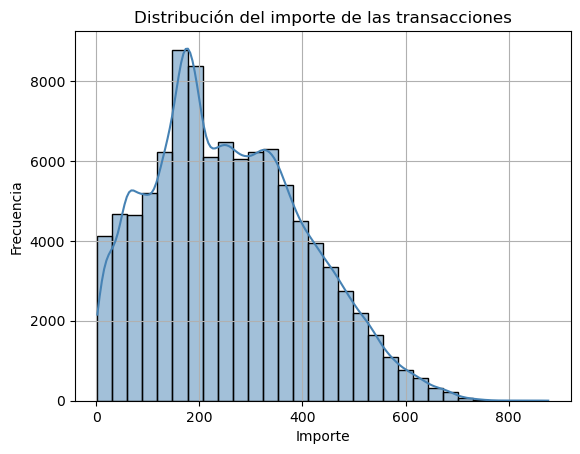

In [146]:
sns.histplot(                    # Histograma para Distribución
    data= transaction,
    x='amount',
    bins = 30,
    kde=True,
    color = 'steelblue');

plt.title("Distribución del importe de las transacciones")
plt.xlabel("Importe")
plt.ylabel("Frecuencia")

plt.grid(True)

plt.show()

Los datos nos muestran que la mayor concentración de transacciones se encuentra entre aproximadamente $150 y $350, con un pico alrededor de los $180–$200. La distribución presenta una asimetría positiva, ya que existen algunas transacciones de importes elevados que generan una cola hacia la derecha, pero la mayoría son de importe medio o bajo.

1.2.2 - Dos variables numéricas.

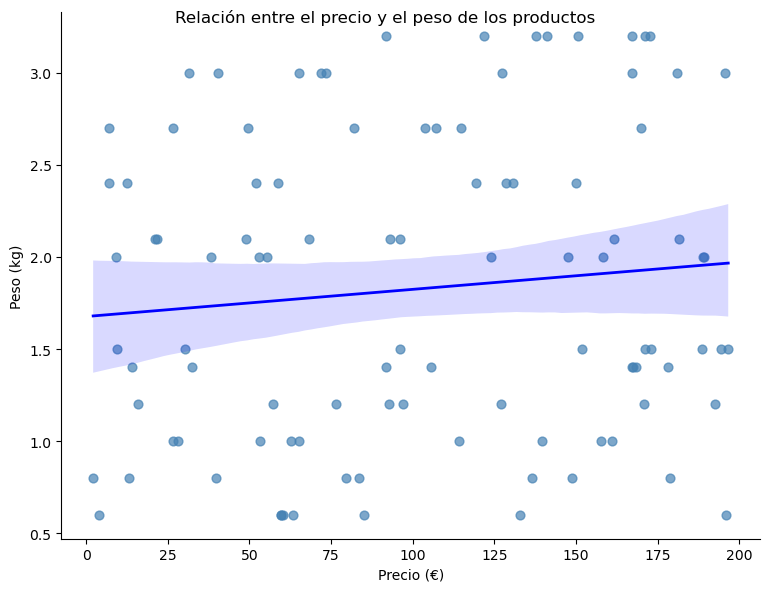

In [109]:
g = sns.lmplot(
    data=products,
    x='price',
    y='weight',
    height=6,                    # Altura
    aspect=1.3,                  # Relación ancho/alto
    scatter_kws={
        'alpha': 0.7,            # Transparencia
        's': 40,                 # Tamaño de los puntos
        'color': 'steelblue'},
    line_kws={'color': 'blue',          # Color de la recta
              'linewidth': 2 })

g.set_axis_labels('Precio (€)', 'Peso (kg)')
g.fig.suptitle('Relación entre el precio y el peso de los productos')

plt.show()

Se muestra la relación entre el precio y el peso de los productos, aunque la línea de tendencia presenta una ligera pendiente positiva, la elevada dispersión de los datos indica que no existe una relación lineal clara entre ambas variables. Por tanto, el peso de los productos no parece ser un factor determinante del precio.

1.2.3 - Una variable categórica.

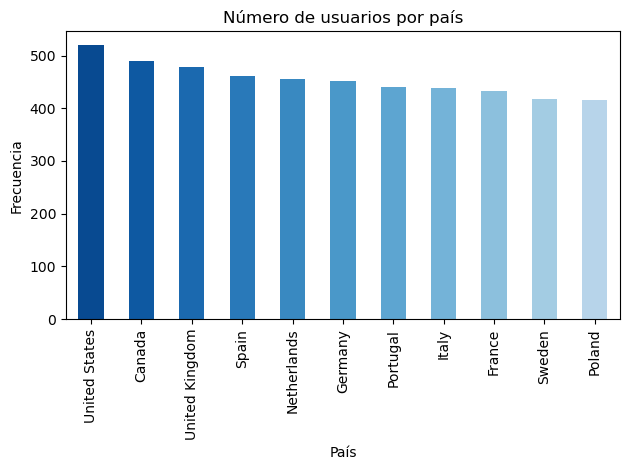

In [147]:
valores = data_user["country"].value_counts()

colores = plt.cm.Blues(np.linspace(0.9, 0.3, len(valores)))

valores.plot.bar(color=colores)

plt.title("Número de usuarios por país")
plt.xlabel("País")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


Se aprecian los países con mayor número de usuarios encabezado por United States, Canada y United Kingdom, aunque se muestra una distribución de clientes bastante homogénea entre los mismos.

1.2.4 - Una variable categórica y una numérica.

In [148]:
mean_amount_status = (users_status.groupby("status")[["total_amount"]].mean().sort_values(by="total_amount", ascending=False).round(2).reset_index())  # reset_index para que vuelva a ser el nombre de la columna y no el indice 
mean_amount_status

,status,total_amount
0,high_value,7727.27
1,medium_value,4924.86
2,low_value,3278.84


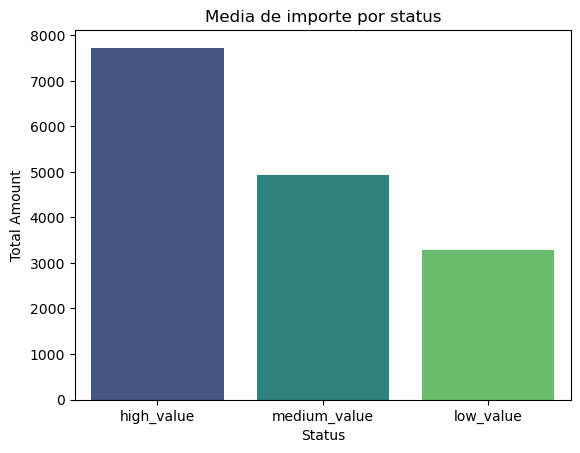

In [ ]:
sns.barplot(
    mean_amount_status,
    x='status',
    y='total_amount',
    hue= 'status',          # Se asume otra variable categórica para que muestre colores diferentes
    palette= 'viridis',
    legend= False
)

plt.title('Media de importe por status')
plt.xlabel('Status')
plt.ylabel('Total Amount')

plt.show()

El gráfico muestra la media del importe (total_amount) para cada categoría de status, lo que permite comparar el comportamiento medio de los distintos grupos de usuarios, ratificando que los usuarios del status high_value hacen transacciones de mayores importes en promedio.

1.2.5 - Dos variables categóricas.

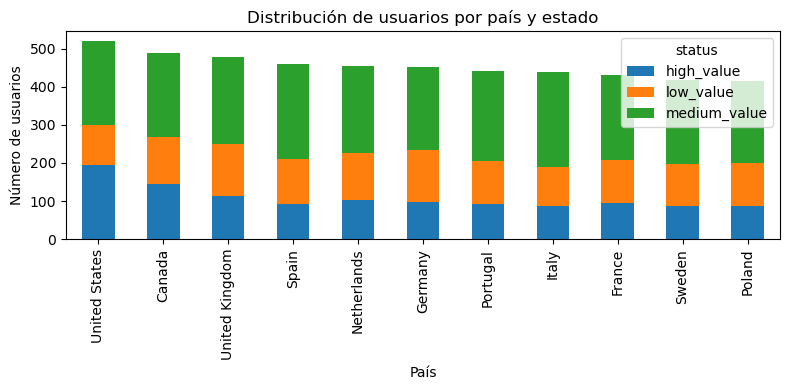

In [150]:
data_user_status = pd.merge(
    data_user,
    users_status,
    left_on='id',
    right_on='user_id')

tabla = pd.crosstab(
    data_user_status['country'],
    data_user_status['status'])

tabla = tabla.loc[tabla.sum(axis=1).sort_values(ascending=False).index]

tabla.plot.bar(stacked=True, figsize=(8,4))

plt.title('Distribución de usuarios por país y estado')
plt.xlabel('País')
plt.ylabel('Número de usuarios')

plt.tight_layout()

plt.show()

El gráfico muestra la distribución de usuarios por país según su status. Se aprecia que Estados Unidos y Canadá son los países con mayor número de usuarios, destacando especialmente la categoría high_value. Además, en estos países las categorías medium_value y low_value presentan una distribución bastante equilibrada, sin diferencias muy marcadas entre ellas.

1.2.6 - Tres variables combinadas.

In [151]:
trans_data_user = pd.merge(transaction, data_user, left_on= 'user_id', right_on= 'id')

fig = px.box(
    trans_data_user,
    x="country",
    y="amount",
    color="declined",
    title="Distribución del importe de las transacciones por país",
    labels={"country": "País",
            "amount": "Importe",
            "declined": "Transacción rechazada"})

fig.update_layout(title_x=0.5)

fig.show()

El gráfico compara la distribución del importe de las transacciones (amount) por país, diferenciando entre transacciones aceptadas (declined = 0) y rechazadas (declined = 1). En general, se observa una elevada dispersión de los importes en la mayoría de los países y la presencia de numerosos valores atípicos. Aunque en algunos países la mediana de las transacciones rechazadas parece superior a la de las aceptadas, no se aprecia un patrón uniforme para todos los países.

1.2.7 - Crea un Pairplot.

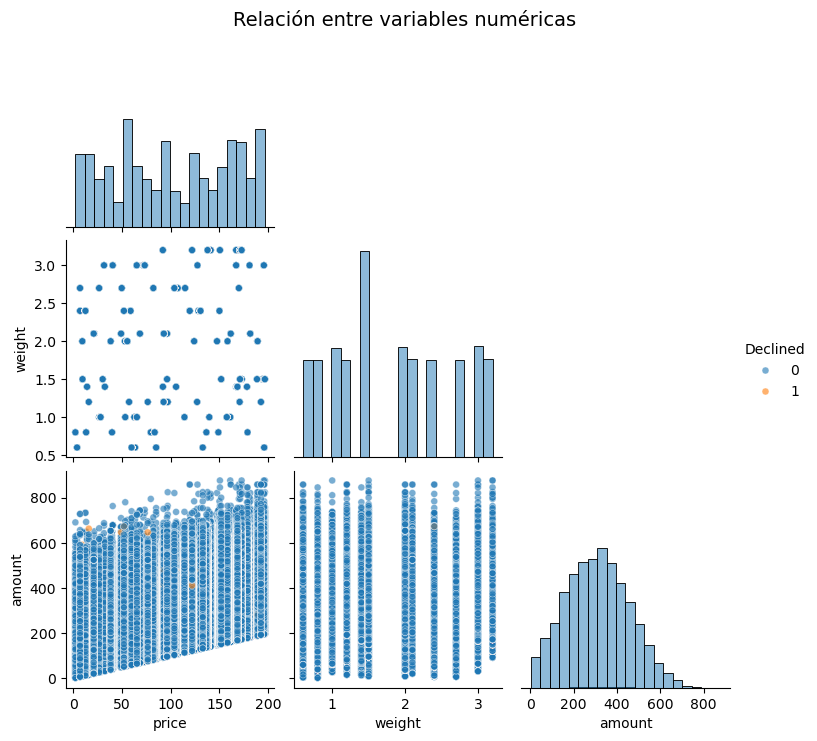

In [152]:
df_intermedio = pd.merge(products, transaction_product, left_on= 'id', right_on= 'products_id')
df_final = pd.merge(df_intermedio, transaction, left_on= 'transaction_id', right_on= 'id')
df_final

g = sns.pairplot(
    df_final,
    vars=["price", "weight", "amount"],
    hue="declined",
    diag_kind="hist",      # Histograma en la diagonal
    corner=True,           # Evita duplicar gráficos
    plot_kws={"alpha": 0.6, "s": 25},   # Transparencia y tamaño de puntos
    diag_kws={"bins": 20}               # Número de barras del histograma
)

g.fig.suptitle('Relación entre variables numéricas',
    fontsize=14)

g._legend.set_title('Declined')

plt.show()
         
  

El pairplot permite analizar las relaciones entre las variables numéricas price, weight y amount, así como la distribución de cada una de ellas. No se observa una relación lineal clara entre price y weight, ni entre weight y el amount de la transacción. Entre price y amount se aprecia una ligera tendencia positiva, aunque la elevada dispersión de los datos indica que la relación es débil.

                                            *** NIVEL 2 *** 

2.1 - Representa la correlación de algunas variables e interpreta los resultados según tus datos.

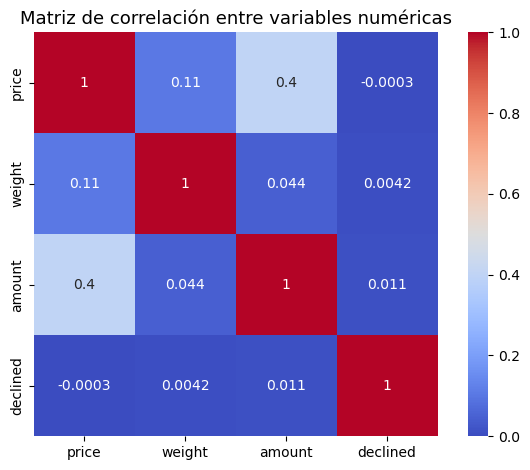

In [153]:
corr = df_final[['price', 'weight', 'amount', 'declined']].corr().round(4)
corr

sns.heatmap(corr, annot=True, cmap='coolwarm', square= True)

plt.title('Matriz de correlación entre variables numéricas', fontsize= 13)
plt.tight_layout()
plt.show()

La matriz de correlación muestra que, en general, las relaciones lineales entre las variables son débiles. La única relación destacable es la existente entre price y amount (0.40), que indica una correlación positiva moderada, mientras que el resto de variables presentan correlaciones muy bajas o prácticamente nulas.

2.2 -  Implementa un Jointplot para explorar la relación entre dos variables e interpreta los resultados según tus datos.

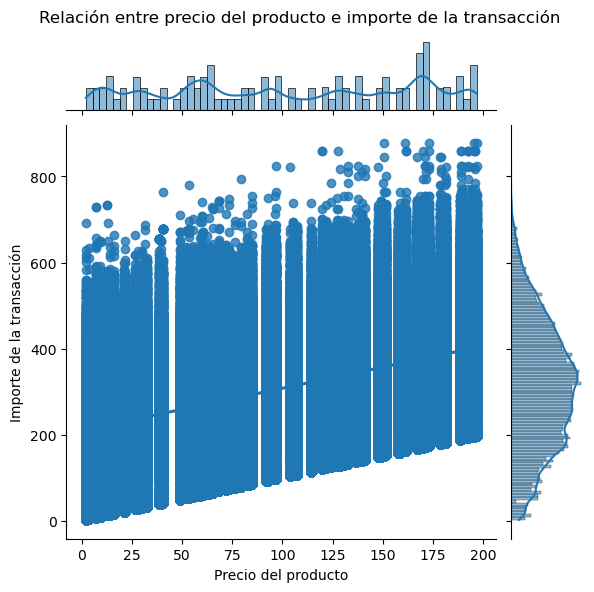

In [154]:
g = sns.jointplot(x= 'price', y='amount', data= df_final, kind='reg')

g.fig.suptitle("Relación entre precio del producto e importe de la transacción")
g.set_axis_labels("Precio del producto", "Importe de la transacción")

g.fig.subplots_adjust(top=0.93)
plt.show()

El gráfico muestra la relación entre el precio del producto y el importe de la transacción, donce se puede observar una tendencia positiva moderada, es decir, a medida que aumenta el precio del producto también tiende a incrementarse el importe de la transacción. Sin embargo, la dispersión de los datos indica que esta relación no es fuerte.

In [155]:
engine.dispose()      # CERRAR LA CONEXION

print("✅ Conexión cerrada.")

✅ Conexión cerrada.
